In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Experiment.potentials import get_potential_energy_CH3CN, get_potential_energy_CH3CN_harmonic
from Experiment.utils import get_orbitals_indices_first,get_ttno
from Experiment.utils_ch3cn import random_mps_harmonic_oscillator_0, random_threetree_harmonic_oscillator_0, random_leafonly_harmonic_oscillator_0
from Experiment.utils import get_ttno
from CheTTNS_A_B import *
from pytreenet.core.truncation.truncating import TruncationMethod
from pytreenet.util import SVDParameters
from Experiment.utils import get_ttno
from Experiment.potentials.potential_CH3CN import get_potential_energy_CH3CN
from pytreenet.ttns.ttns_ttno.application import apply_and_truncate, apply_ttno_to_ttns, ApplicationMethod
from pytreenet.ttns.ttns_ttno.zipup import zipup
import copy
from pytreenet.operators.common_operators import *

### Build random TTNS and TTNO---Sun shuo

In [3]:
N = [2,2,2,2,2,2,2,2,2,2,2,2]
node_order = [0,1,2,3,4,5,6,7,8,9,10,11]

omega, _, _ = get_potential_energy_CH3CN_harmonic()

_, orb_state, orb_Es = get_orbitals_indices_first(omega, num_orb=1)

random_ttns = random_threetree_harmonic_oscillator_0(N, omega, orb_state[0].reshape(1, -1), node_order)

random_ttns.canonical_form(random_ttns.root_id)

random_ttno, _ = get_ttno(N, random_ttns, get_potential_energy_CH3CN, True)

site_ids = list(random_ttns.nodes.keys())
print("Number of sites:", len(site_ids))
print("Site ids:", site_ids)

/Users/link/Desktop/A_Python_code/Chebyshev/pytreenet/random/random_node.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  rand_tensor = crandn(shape, seed=seed).astype(dtype)


Number of sites: 13
Site ids: ['site12', 'site3', 'site2', 'site1', 'site0', 'site4', 'site5', 'site6', 'site7', 'site8', 'site9', 'site10', 'site11']


### Correct result

In [4]:
ttno_matrix, _ = random_ttno.as_matrix()
ttns_vector, _ = random_ttns.to_vector(True)
v = ttno_matrix @ ttns_vector
norm = np.linalg.norm(v)
v = v / norm

### Zipup contraction

In [5]:
v_zip = copy.deepcopy(v)
ttno_zip  = copy.deepcopy(random_ttno)
ttns_zip = copy.deepcopy(random_ttns)
svd_params = SVDParameters(max_bond_dim=float("inf"), rel_tol=0.0, total_tol=0.0, sum_trunc=False)
psi_zip = zipup(ttno_zip, ttns_zip, svd_params)
psi_zip.normalise()
print(psi_zip.max_bond_dim())
print('The fidelity is', abs(np.vdot(psi_zip.to_vector(True)[0], v_zip)))

16
The fidelity is 0.9999999999999998


### Direct contraction then truncate

In [6]:
v_dir = copy.deepcopy(v)
ttns_dir = copy.deepcopy(random_ttns)
ttno_dir = copy.deepcopy(random_ttno)
svd_params = SVDParameters(max_bond_dim = 2, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
psi_dir = apply_and_truncate(ttns=ttns_dir, ttno=ttno_dir, app_method=ApplicationMethod.DIRECT, trunc_method=TruncationMethod.RECURSIVE,
trunc_args=(svd_params,))
# psi_dir = apply_ttno_to_ttns(ttns=ttns_dir, ttno=ttno_dir, method=ApplicationMethod.DIRECT_TRUNCATE, params=svd_params)
psi_dir.normalise()
print(psi_dir.max_bond_dim())
print('The fidelity is', abs(np.vdot(psi_dir.to_vector(True)[0], v_dir)))

2
The fidelity is 0.9976433760794006


### Density Matrix

In [7]:
v_dm = copy.deepcopy(v)
ttns_dm = copy.deepcopy(random_ttns)
ttno_dm = copy.deepcopy(random_ttno)
svd_params = SVDParameters(max_bond_dim = 60, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
psi_dm = apply_ttno_to_ttns(ttns=ttns_dm, ttno=ttno_dm, method=ApplicationMethod.DENSITY_MATRIX, svd_params=svd_params)
psi_dm.normalise()
print(psi_dm.max_bond_dim())
print('The fidelity is', abs(np.vdot(psi_dm.to_vector(True)[0], v_dm)))

16
The fidelity is 1.0000000000000004


### Half density matrix

In [8]:
v_HDM = copy.deepcopy(v)
ttns_HDM = copy.deepcopy(random_ttns)
ttno_HDM = copy.deepcopy(random_ttno)
svd_params = SVDParameters(max_bond_dim = 50, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
psi_HDM = apply_ttno_to_ttns(ttns=ttns_HDM, ttno=ttno_HDM, method=ApplicationMethod.HALF_DENSITY_MATRIX, svd_params=svd_params)
psi_HDM.normalise()
print(psi_HDM.max_bond_dim())
print('The fidelity is', abs(np.vdot(psi_HDM.to_vector(True)[0], v_HDM)))

16
The fidelity is 0.9999999999999997


### SRC

In [9]:
v_SRC = copy.deepcopy(v)
ttns_SRC = copy.deepcopy(random_ttns)
ttno_SRC = copy.deepcopy(random_ttno)
svd_params = SVDParameters(max_bond_dim = 60, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
psi_SRC = apply_ttno_to_ttns(ttns=ttns_SRC, ttno=ttno_SRC, method=ApplicationMethod.SRC, desired_dimension = 60)
psi_SRC.normalise()
print(psi_SRC.max_bond_dim())
print('The fidelity is', abs(np.vdot(psi_SRC.to_vector(True)[0], v_SRC)))

16
The fidelity is 1.0000000000000004


### Variational

In [10]:
v_var = copy.deepcopy(v)
ttns_var = copy.deepcopy(random_ttns)
ttno_var = copy.deepcopy(random_ttno)
svd_params = SVDParameters(max_bond_dim = 20, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
psi_var = apply_ttno_to_ttns(ttns=ttns_var, ttno=ttno_var, method=ApplicationMethod.VARIATIONAL, svd_params=svd_params)
psi_var.normalise()
print(psi_var.max_bond_dim())
print('The fidelity is', abs(np.vdot(psi_var.to_vector(True)[0], v_var)))

20
The fidelity is 0.0031818249154448278


### Half Density Matrix Variational

In [11]:
v_HDMV = copy.deepcopy(v)
ttns_HDMV = copy.deepcopy(random_ttns)
ttno_HDMV = copy.deepcopy(random_ttno)
dm_svd_params = SVDParameters(max_bond_dim = 90, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
var_svd_params = SVDParameters(max_bond_dim = 30, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
psi_HDMV = apply_ttno_to_ttns(ttns=ttns_HDMV, ttno=ttno_HDMV, method=ApplicationMethod.HALF_DENSITY_MATRIX_VARIATIONAL, dm_svd_params=dm_svd_params, 
                              var_svd_params=var_svd_params)
psi_HDMV.normalise()
print(psi_HDMV.max_bond_dim())
print('The fidelity is', abs(np.vdot(psi_HDMV.to_vector(True)[0], v_HDMV)))

30
The fidelity is 1.0000000000000004


### Zip up variational

In [12]:
v_zip_var = copy.deepcopy(v)
ttns_zip_var = copy.deepcopy(random_ttns)
ttno_zip_var = copy.deepcopy(random_ttno)
zipup_svd_params = SVDParameters(max_bond_dim = 90, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
var_svd_params = SVDParameters(max_bond_dim = 20, rel_tol=0.0, total_tol=0.0, sum_trunc=False)
psi_zip_var = apply_ttno_to_ttns(ttns=ttns_zip_var, ttno=ttno_zip_var, method=ApplicationMethod.ZIPUP_VARIATIONAL, var_svd_params=var_svd_params, 
                              zipup_svd_params=zipup_svd_params)
psi_zip_var.normalise()
print(psi_zip_var.max_bond_dim())
print('The fidelity is', abs(np.vdot(psi_zip_var.to_vector(True)[0], v_zip_var)))

20
The fidelity is 0.9999999999999997


### Fidelity VS Max bond_dim

Zipup               chi_req=   1  chi_act=   1  fid=0.0007432364720048
Direct+Truncate     chi_req=   1  chi_act=   1  fid=0.9999714995912554
DensityMatrix       chi_req=   1  chi_act=   1  fid=0.9999741476487680
HalfDensityMatrix   chi_req=   1  chi_act=   1  fid=0.0000000000037068
SRC                 chi_req=   1  chi_act=   1  fid=0.9998371003971440
Zipup               chi_req=   3  chi_act=   3  fid=0.0019444077892095
Direct+Truncate     chi_req=   3  chi_act=   3  fid=0.9974040916213401
DensityMatrix       chi_req=   3  chi_act=   3  fid=0.9999897605022026
HalfDensityMatrix   chi_req=   3  chi_act=   3  fid=0.0000000000683649
SRC                 chi_req=   3  chi_act=   3  fid=0.9999650752292639
Zipup               chi_req=   5  chi_act=   5  fid=0.0025150707678439
Direct+Truncate     chi_req=   5  chi_act=   5  fid=0.9999938532798516
DensityMatrix       chi_req=   5  chi_act=   5  fid=0.9999960473646221
HalfDensityMatrix   chi_req=   5  chi_act=   5  fid=0.1591330399751372
SRC   

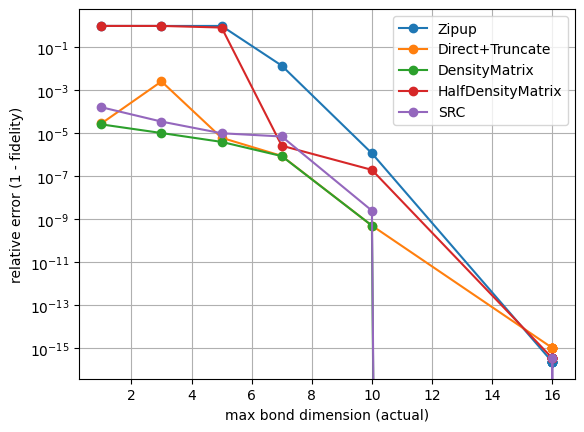

In [13]:
def fidelity(vec1, vec2):
    return abs(np.vdot(vec1, vec2))

def run_zipup(ttno, ttns, v, chi):
    ttno_z = copy.deepcopy(ttno)
    ttns_z = copy.deepcopy(ttns)

    svd_params = SVDParameters(
        max_bond_dim=chi,
        rel_tol=0.0,
        total_tol=0.0,
        sum_trunc=False
    )
    psi = zipup(ttno_z, ttns_z, svd_params)
    psi.normalise()
    psi_vec = psi.to_vector(True)[0]
    return psi.max_bond_dim(), fidelity(psi_vec, v)

def run_direct_truncate(ttno, ttns, v, chi):
    ttno_dir = copy.deepcopy(ttno)
    ttns_dir = copy.deepcopy(ttns)
    svd_params = SVDParameters(max_bond_dim=chi, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

    psi = apply_and_truncate(
        ttns=ttns_dir,
        ttno=ttno_dir,
        app_method=ApplicationMethod.DIRECT,
        trunc_method=TruncationMethod.RECURSIVE,
        trunc_args=(svd_params,)
    )
    psi.normalise()
    psi_vec = psi.to_vector(True)[0]
    return psi.max_bond_dim(), fidelity(psi_vec, v)

def run_density_matrix(ttno, ttns, v, chi):
    ttno_dm = copy.deepcopy(ttno)
    ttns_dm = copy.deepcopy(ttns)
    svd_params = SVDParameters(max_bond_dim=chi, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

    psi = apply_ttno_to_ttns(
        ttns=ttns_dm,
        ttno=ttno_dm,
        method=ApplicationMethod.DENSITY_MATRIX,
        svd_params=svd_params
    )
    psi.normalise()
    psi_vec = psi.to_vector(True)[0]
    return psi.max_bond_dim(), fidelity(psi_vec, v)

def run_half_density_matrix(ttno, ttns, v, chi):
    ttno_hdm = copy.deepcopy(ttno)
    ttns_hdm = copy.deepcopy(ttns)
    svd_params = SVDParameters(max_bond_dim=chi, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

    psi = apply_ttno_to_ttns(
        ttns=ttns_hdm,
        ttno=ttno_hdm,
        method=ApplicationMethod.HALF_DENSITY_MATRIX,
        svd_params=svd_params
    )
    psi.normalise()
    psi_vec = psi.to_vector(True)[0]
    return psi.max_bond_dim(), fidelity(psi_vec, v)

def run_src(ttno, ttns, v, chi):
    ttno_src = copy.deepcopy(ttno)
    ttns_src = copy.deepcopy(ttns)

    psi = apply_ttno_to_ttns(
        ttns=ttns_src,
        ttno=ttno_src,
        method=ApplicationMethod.SRC,
        desired_dimension=chi
    )
    psi.normalise()
    psi_vec = psi.to_vector(True)[0]
    return psi.max_bond_dim(), fidelity(psi_vec, v)

chis = [1, 3, 5, 7, 10, 20, 30, 40, 50, 60, 70, 80]

methods = {
    "Zipup": run_zipup,
    "Direct+Truncate": run_direct_truncate,
    "DensityMatrix": run_density_matrix,
    "HalfDensityMatrix": run_half_density_matrix,
    "SRC": run_src,
}

results = {name: {"chi_req": [], "chi_act": [], "fid": []} for name in methods}

for chi in chis:
    for name, fn in methods.items():
        chi_act, fid = fn(random_ttno, random_ttns, v, chi)
        results[name]["chi_req"].append(chi)
        results[name]["chi_act"].append(chi_act)
        results[name]["fid"].append(fid)
        print(f"{name:18s}  chi_req={chi:4d}  chi_act={chi_act:4d}  fid={fid:.16f}")

# 画图（横轴用实际达到的 max bond dim）
plt.figure()
for name in methods:
    x = results[name]["chi_act"]
    fid = np.array(results[name]["fid"])
    y = 1.0 - fid          # relative error
    plt.plot(x, y, marker="o", label=name)

plt.xlabel("max bond dimension (actual)")
plt.ylabel("relative error (1 - fidelity)")
plt.yscale("log")
plt.grid(True, which="both")
plt.legend()
plt.show()


DensityMatrix  chi_req=   1 chi_act=   1 time=4.266292e-03s ± 1.05e-04
SRC            chi_req=   1 chi_act=   1 time=3.237083e-03s ± 2.09e-04
HalfDM         chi_req=   1 chi_act=   1 time=2.679042e-03s ± 3.49e-05
DensityMatrix  chi_req=   3 chi_act=   3 time=4.149333e-03s ± 2.14e-04
SRC            chi_req=   3 chi_act=   3 time=3.797583e-03s ± 2.93e-04
HalfDM         chi_req=   3 chi_act=   3 time=3.083375e-03s ± 5.90e-05
DensityMatrix  chi_req=   5 chi_act=   5 time=5.551084e-03s ± 1.61e-04
SRC            chi_req=   5 chi_act=   5 time=6.582709e-03s ± 3.59e-04
HalfDM         chi_req=   5 chi_act=   5 time=4.716208e-03s ± 1.84e-04
DensityMatrix  chi_req=   7 chi_act=   7 time=8.131375e-03s ± 2.07e-04
SRC            chi_req=   7 chi_act=   7 time=1.163433e-02s ± 2.31e-04
HalfDM         chi_req=   7 chi_act=   7 time=7.120708e-03s ± 4.91e-04
DensityMatrix  chi_req=  10 chi_act=  10 time=1.586250e-02s ± 2.24e-04
SRC            chi_req=  10 chi_act=  10 time=2.763583e-02s ± 2.42e-04
HalfDM

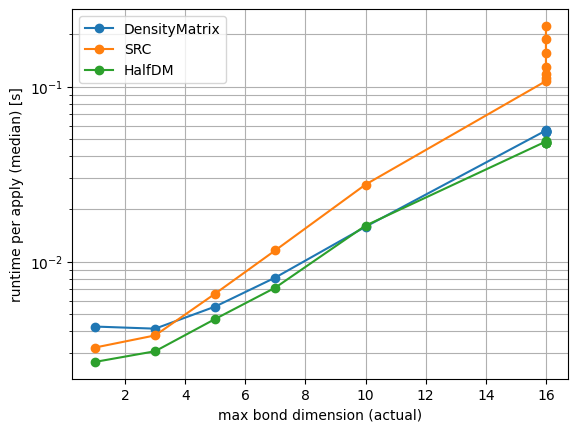

In [14]:
import time
import numpy as np
import copy
import matplotlib.pyplot as plt


def run_half_density_matrix_speed(ttno, ttns, chi):
    ttno_hdm = copy.deepcopy(ttno)
    ttns_hdm = copy.deepcopy(ttns)
    svd_params = SVDParameters(max_bond_dim=chi, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

    psi = apply_ttno_to_ttns(
        ttns=ttns_hdm,
        ttno=ttno_hdm,
        method=ApplicationMethod.HALF_DENSITY_MATRIX,
        svd_params=svd_params
    )
    return psi.max_bond_dim()


def run_density_matrix_speed(ttno, ttns, chi):
    ttno_dm = copy.deepcopy(ttno)
    ttns_dm = copy.deepcopy(ttns)
    svd_params = SVDParameters(max_bond_dim=chi, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

    psi = apply_ttno_to_ttns(
        ttns=ttns_dm,
        ttno=ttno_dm,
        method=ApplicationMethod.DENSITY_MATRIX,
        svd_params=svd_params
    )
    return psi.max_bond_dim()

def run_src_speed(ttno, ttns, chi):
    ttno_src = copy.deepcopy(ttno)
    ttns_src = copy.deepcopy(ttns)

    psi = apply_ttno_to_ttns(
        ttns=ttns_src,
        ttno=ttno_src,
        method=ApplicationMethod.SRC,
        desired_dimension=chi
    )
    return psi.max_bond_dim()

def time_one_speed(fn, ttno, ttns, chi, repeats=7, warmup=1):
    # warmup
    for _ in range(warmup):
        fn(ttno, ttns, chi)

    ts = []
    chi_acts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        chi_act = fn(ttno, ttns, chi)
        t1 = time.perf_counter()
        ts.append(t1 - t0)
        chi_acts.append(chi_act)

    return int(np.median(chi_acts)), float(np.median(ts)), float(np.std(ts))

chis = [1, 3, 5, 7, 10, 20, 30, 40, 50, 60, 70, 80]

methods_speed = {
    "DensityMatrix": run_density_matrix_speed,
    "SRC": run_src_speed,
    "HalfDM": run_half_density_matrix_speed,
}

speed_results = {name: {"chi_req": [], "chi_act": [], "time_med": [], "time_std": []}
                 for name in methods_speed}

repeats = 7
warmup = 1

for chi in chis:
    for name, fn in methods_speed.items():
        chi_act, t_med, t_std = time_one_speed(fn, random_ttno, random_ttns, chi,
                                               repeats=repeats, warmup=warmup)
        speed_results[name]["chi_req"].append(chi)
        speed_results[name]["chi_act"].append(chi_act)
        speed_results[name]["time_med"].append(t_med)
        speed_results[name]["time_std"].append(t_std)

        print(f"{name:14s} chi_req={chi:4d} chi_act={chi_act:4d} "
              f"time={t_med:.6e}s ± {t_std:.2e}")


plt.figure()
for name in methods_speed:
    x = np.array(speed_results[name]["chi_act"])
    y = np.array(speed_results[name]["time_med"])
    plt.plot(x, y, marker="o", label=name)

plt.xlabel("max bond dimension (actual)")
plt.ylabel("runtime per apply (median) [s]")
plt.yscale("log")
plt.grid(True, which="both")
plt.legend()
plt.show()
